# Linear Regression & Regularization

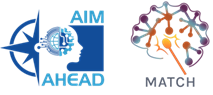

**Objectives:**


*   Obtain an estimate for a missing BMI value using a linear regressor trained on the rest of our dataset, and a known weight value.
*   Visualize the linear regressor
* Calculate the coefficient of determination



**Acknowledgements** <br>
aiMATCH Hands-on Workshop Series: Predictive modeling using healthcare data. NIH AIM AHEAD DICB Program <br>
Principal Investigator: Amina Qutub, Ph.D., University of Texas at San Antonio<br>
Workshop Presenter and Code Author: Mignon Dumanjog, M.S., University of Texas at San Antonio<br>

# Import packages & data

You can either load the data from Kaggle (through an API token which can be obtained from your Kaggle settings page), or from local files by uploading *train.csv*, *test.csv*, and *solution.csv* from the [aiMATCH GitHub page.](https://github.com/qutublab/aiMATCH/releases/tag/Predictive-modeling-workshop)<br>Run the cell corresponding to your chosen method.

In [ ]:
import numpy as np
import pandas as pd
import os

*From Kaggle*

In [ ]:
# NEVER SHARE YOUR API TOKEN PUBLICLY.
# Tip: Store your API token as a Secret in Google Colab.
# If running locally, do not commit your .env file or it will expose secrets
# that will allow others to control access to your various AI and authentication provider accounts.
import kagglehub
kagglehub.login()

aimatch_workshop_predicting_health_outcomes_path = kagglehub.competition_download('aimatch-workshop-predicting-health-outcomes')

print('Data source import complete.')

train_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Train.csv'))


Data source import complete.
Kaggle credentials set.
Kaggle credentials successfully validated.


*From files*

In [ ]:
train_df = pd.read_csv('/path/Train.csv') # change to actual path

# Display missing value
In this notebook, we will estimate a BMI value for one of the patients in our training dataset, using a linear regressor based on the rest of our training data and the patient's known weight value.

In [ ]:
missing_BMI_Patient = train_df.iloc[48,:]
print('Info for the patient with missing a BMI value:')
display(missing_BMI_Patient)

Info for the patient with missing a BMI value:


,48
UPIN,1000083
FAB.(Assigned),M2
Age.Dx,59
Age.subgroup,>60
Weight.kg,120.554452
BMI,NaN
HCT,26.363605
Dysplasia,NaN
Protein A,0.172275
Protein B,1.603881


Let's visualize the training dataset for our linear regressor.

In [ ]:
filtered = train_df[['BMI', 'Weight.kg']].dropna()

BMI_values = filtered['BMI'].to_numpy()
Weight_values = filtered['Weight.kg'].to_numpy()

print('BMI values shape:', BMI_values.shape, BMI_values)
print('Weight values shape:', Weight_values.shape, Weight_values)

BMI values shape: (61,) [27.77690223 30.93139682 27.68377796 22.33116726 31.80049159 24.71172396
 22.8082323  28.79364125 26.51836746 34.4146675  25.38900892 27.37751055
 31.79284454 21.91417253 32.2792095  26.57237226 23.48835397 22.52117339
 24.76432817 25.98924326 51.42548279 22.58427356 24.5764637  32.07375104
 28.59958322 23.32754128 30.50021459 31.215371   26.53944954 21.10908439
 33.81764308 35.10707518 26.78785317 22.83137368 53.77951464 30.71301253
 40.95650342 30.63656261 38.01345591 28.41050933 24.34224046 27.46590085
 30.29328043 22.36634059 32.20350673 35.42164358 31.69529481 52.41912332
 29.45651421 34.59340896 23.22169722 36.9858377  25.22832544 26.22486578
 18.79450904 32.49198113 23.31154172 27.18437282 30.14235606 26.46495365
 23.10693926]
Weight values shape: (61,) [ 85.77664425  90.36990416  90.04479975  52.50681065  82.11595436
  79.15360923  63.5388348   62.07422262  77.37562121 117.5827962
  92.67377437  70.86161506  98.59687819  49.53498405  81.31609854
  67.045

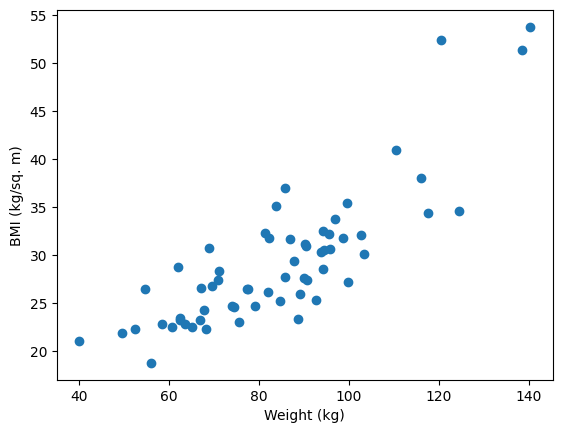

In [ ]:
# Scatter plot for our training dataset
import matplotlib.pyplot as plt
plt.scatter(Weight_values, BMI_values)
plt.xlabel('Weight (kg)')
plt.ylabel('BMI (kg/sq. m)')
plt.show()

# Linear regressor


In [ ]:
from sklearn.linear_model import LinearRegression

lg = LinearRegression()

X = Weight_values.reshape(-1,1)
y = BMI_values

lg.fit(X,y)

LinearRegression()

In [ ]:
predicted_BMI_value = lg.predict(missing_BMI_Patient['Weight.kg'].reshape(-1,1))[0]
print(f'This is our predicted BMI value given patient weight {round(missing_BMI_Patient['Weight.kg'],2)} kg: predicted_BMI_value')

This is our predicted BMI value given patient weight 120.55 kg: predicted_BMI_value


Visualizing our linear model and the predicted value

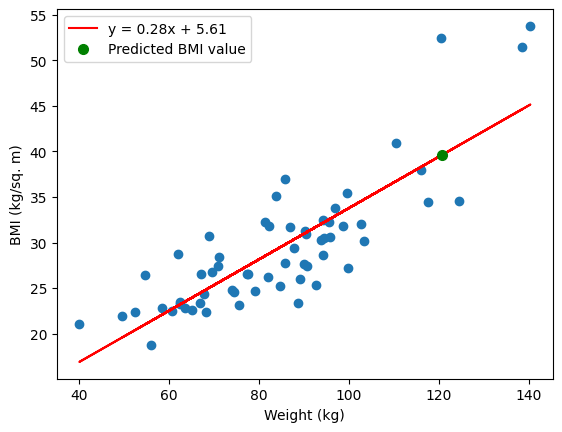

In [ ]:
plt.scatter(Weight_values, BMI_values)

BMI_preds = np.array([lg.predict(x.reshape(-1, 1))[0] for x in Weight_values])
predicted_BMI_value
plt.plot(Weight_values, BMI_preds, color='red', label=f'y = {round(lg.coef_[0],2)}x + {round(lg.intercept_,2)}')
plt.plot(missing_BMI_Patient['Weight.kg'],predicted_BMI_value, 'go', markersize=7, label=f'Predicted BMI value')
plt.xlabel('Weight (kg)')
plt.ylabel('BMI (kg/sq. m)')
plt.legend()
plt.show()

The coefficient of determination or score

In [ ]:
print('Score:', lg.score(X,y))
print('Mean BMI:', np.mean(BMI_values))

Score: 0.6888971090229352
Mean BMI: 29.28324488262295


# A closer look at MSE minimization

In [ ]:
X_with_bias = np.c_[np.ones(X.shape[0]), X]
print(X_with_bias)

[[  1.          85.77664425]
 [  1.          90.36990416]
 [  1.          90.04479975]
 [  1.          52.50681065]
 [  1.          82.11595436]
 [  1.          79.15360923]
 [  1.          63.5388348 ]
 [  1.          62.07422262]
 [  1.          77.37562121]
 [  1.         117.5827962 ]
 [  1.          92.67377437]
 [  1.          70.86161506]
 [  1.          98.59687819]
 [  1.          49.53498405]
 [  1.          81.31609854]
 [  1.          67.04574251]
 [  1.          62.45111146]
 [  1.          60.67946208]
 [  1.          74.07699122]
 [  1.          89.09702014]
 [  1.         138.5164777 ]
 [  1.          65.16095743]
 [  1.          74.45487404]
 [  1.         102.5637536 ]
 [  1.          94.28278094]
 [  1.          88.73300905]
 [  1.          94.36757785]
 [  1.          90.20178026]
 [  1.          77.63215641]
 [  1.          40.06727501]
 [  1.          96.80732943]
 [  1.          83.87839307]
 [  1.          69.55108599]
 [  1.          58.54164367]
 [  1.        

In [ ]:
y_column = y.reshape(-1,1)
y_column

array([[27.77690223],
       [30.93139682],
       [27.68377796],
       [22.33116726],
       [31.80049159],
       [24.71172396],
       [22.8082323 ],
       [28.79364125],
       [26.51836746],
       [34.4146675 ],
       [25.38900892],
       [27.37751055],
       [31.79284454],
       [21.91417253],
       [32.2792095 ],
       [26.57237226],
       [23.48835397],
       [22.52117339],
       [24.76432817],
       [25.98924326],
       [51.42548279],
       [22.58427356],
       [24.5764637 ],
       [32.07375104],
       [28.59958322],
       [23.32754128],
       [30.50021459],
       [31.215371  ],
       [26.53944954],
       [21.10908439],
       [33.81764308],
       [35.10707518],
       [26.78785317],
       [22.83137368],
       [53.77951464],
       [30.71301253],
       [40.95650342],
       [30.63656261],
       [38.01345591],
       [28.41050933],
       [24.34224046],
       [27.46590085],
       [30.29328043],
       [22.36634059],
       [32.20350673],
       [35

In [ ]:
theta = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
theta

array([5.60515251, 0.28186434])

# Regularization

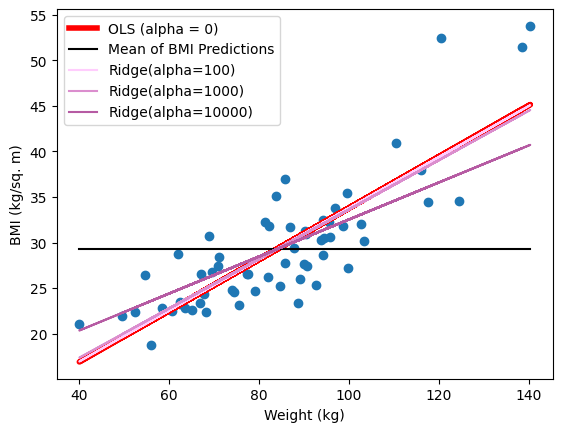

In [ ]:
# Ridge
from sklearn import linear_model

rr0 = linear_model.Ridge(alpha=100).fit(X,y)
rr1 = linear_model.Ridge(alpha=1000).fit(X,y)
rr2 = linear_model.Ridge(alpha=10000).fit(X,y)

ridge_regressors = [rr0, rr1, rr2]

# Plot
colors = plt.cm.vanimo(np.linspace(0, 1, 12)) # Generate color map

plt.plot(Weight_values, BMI_preds, color='red', linewidth=4, label=f'OLS (alpha = 0)')
plt.plot([x for x in np.linspace(min(Weight_values),max(Weight_values),len(Weight_values))], [np.mean(BMI_preds) for x in np.linspace(np.min(BMI_preds),np.max(BMI_preds),len(BMI_preds))], color='k',  label='Mean of BMI Predictions')
plt.scatter(Weight_values, BMI_values)

color_i = 0
for reg in ridge_regressors:
    predicted_BMI = np.array([reg.predict(x.reshape(-1, 1))[0] for x in Weight_values])
    plt.plot(Weight_values, predicted_BMI, label=f'{reg}', color=colors[color_i])
    color_i += 1
plt.legend()
plt.xlabel('Weight (kg)')
plt.ylabel('BMI (kg/sq. m)')
plt.show()

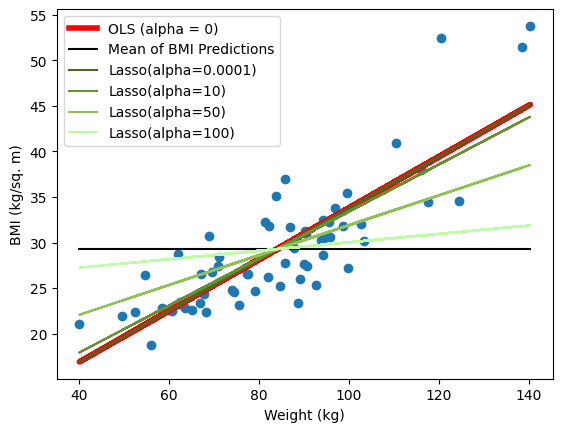

In [ ]:
# LASSO
from sklearn.linear_model import Lasso
lr0 = Lasso(alpha=0.0001).fit(X, y)
lr1 = Lasso(alpha=10).fit(X, y)
lr2 = Lasso(alpha=50).fit(X, y)
lr3 = Lasso(alpha=100).fit(X, y)

lasso_regressors = [lr0,lr1,lr2,lr3]



plt.plot(Weight_values, BMI_preds, color='red', linewidth=4, label=f'OLS (alpha = 0)')
plt.plot([x for x in np.linspace(min(Weight_values),max(Weight_values),len(Weight_values))], [np.mean(BMI_preds) for x in np.linspace(np.min(BMI_preds),np.max(BMI_preds),len(BMI_preds))], color='k',  label='Mean of BMI Predictions')
plt.scatter(Weight_values, BMI_values)

color_i = 8
for reg in lasso_regressors:
    predicted_BMI = np.array([reg.predict(x.reshape(-1, 1))[0] for x in Weight_values])
    plt.plot(Weight_values, predicted_BMI, label=f'{reg}', color=colors[color_i])
    color_i += 1
plt.legend()
plt.xlabel('Weight (kg)')
plt.ylabel('BMI (kg/sq. m)')
plt.show()

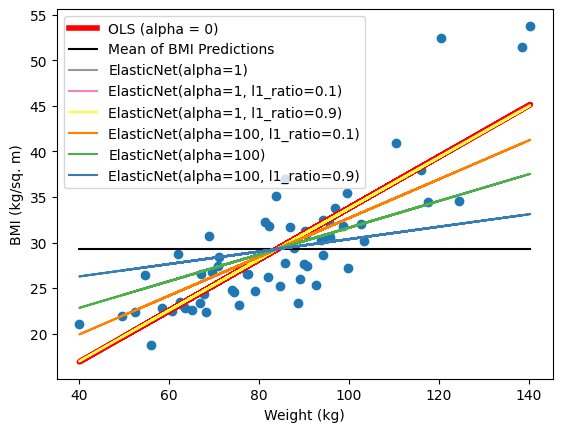

In [ ]:
# Elastic-Net
from sklearn.linear_model import ElasticNet
enr0 = ElasticNet(alpha=1, l1_ratio=0.5).fit(X,y)
enr1 = ElasticNet(alpha=1, l1_ratio=0.1).fit(X,y)
enr2 = ElasticNet(alpha=1, l1_ratio=0.9).fit(X,y)
enr3 = ElasticNet(alpha=100, l1_ratio=0.1).fit(X,y)
enr4 = ElasticNet(alpha=100, l1_ratio=0.5).fit(X,y)
enr5 = ElasticNet(alpha=100, l1_ratio=0.9).fit(X,y)

colors_e = plt.cm.Set1_r(np.linspace(0, 1, 7))
en_regressors = [enr0,enr1,enr2,enr3,enr4,enr5]
plt.plot(Weight_values, BMI_preds, color='red', linewidth=4, label=f'OLS (alpha = 0)')
plt.plot([x for x in np.linspace(min(Weight_values),max(Weight_values),len(Weight_values))], [np.mean(BMI_preds) for x in np.linspace(np.min(BMI_preds),np.max(BMI_preds),len(BMI_preds))], color='k',  label='Mean of BMI Predictions')
plt.scatter(Weight_values, BMI_values)

color_i=0
for reg in en_regressors:
    predicted_BMI = np.array([reg.predict(x.reshape(-1, 1))[0] for x in Weight_values])
    plt.plot(Weight_values, predicted_BMI, label=f'{reg}', color=colors_e[color_i])
    color_i += 1
plt.legend()
plt.xlabel('Weight (kg)')
plt.ylabel('BMI (kg/sq. m)')
plt.show()